<a href="https://colab.research.google.com/github/gajan0918/LD6053-dissertation/blob/main/LD6051_ML_Group_Student_Performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LD6051 Machine Learning on Cloud — Group Project Technical Notebook
## Student Academic Performance Classification

This notebook provides the reproducible technical implementation and supporting evidence for the LD6051 Machine Learning on Cloud group project. It develops and evaluates a multiclass classifier for **Low**, **Medium** and **High** student performance using the supplied `StudentPerformanceFactors.csv` dataset.

The workflow covers environment control, data ingestion and validation, exploratory data analysis, target construction, leakage-safe preprocessing, cross-validation, model comparison, ablation experiments, training-only hyperparameter optimisation, held-out evaluation, error analysis, explainability, threshold sensitivity, fairness diagnostics and model persistence.

The held-out test partition is not used for model-family selection or hyperparameter optimisation.


## 1. Environment setup and reproducibility

A fixed random seed is used for stochastic operations, and package versions are recorded. Warnings are not globally suppressed because convergence or compatibility warnings are useful technical evidence and should be investigated rather than hidden.

In [ ]:
import os, sys, json, warnings, subprocess, platform, hashlib
from pathlib import Path

os.environ['PYTHONHASHSEED'] = '42'
warnings.filterwarnings('default')

try:
    import imblearn
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'imbalanced-learn'])
    import imblearn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import sklearn

from IPython.display import display
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate,
    cross_val_score, GridSearchCV
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder, StandardScaler, OrdinalEncoder,
    LabelEncoder, label_binarize
)
from sklearn.feature_selection import SelectPercentile, f_classif
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_recall_fscore_support, classification_report,
    confusion_matrix, roc_auc_score, roc_curve, auc
)
from sklearn.inspection import permutation_importance
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler, SMOTENC
from imblearn.under_sampling import RandomUnderSampler

RANDOM_STATE = 42
EVIDENCE_DIR = Path('ld6051_evidence')
FIG_DIR = EVIDENCE_DIR / 'figures'
EVIDENCE_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

versions = {
    'python': sys.version.split()[0],
    'platform': platform.platform(),
    'pandas': pd.__version__,
    'numpy': np.__version__,
    'scikit_learn': sklearn.__version__,
    'imbalanced_learn': imblearn.__version__
}
print(json.dumps(versions, indent=2))
(EVIDENCE_DIR / 'environment_versions.json').write_text(
    json.dumps(versions, indent=2)
)

PLOT_DPI = 300
plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': PLOT_DPI,
    'font.size': 10.5,
    'axes.titlesize': 12,
    'axes.labelsize': 10.5,
    'xtick.labelsize': 9.5,
    'ytick.labelsize': 9.5,
    'legend.fontsize': 9
})

def save_figure(fig, filename):
    fig.tight_layout()
    fig.savefig(FIG_DIR / filename, dpi=PLOT_DPI, bbox_inches='tight')
    plt.show()
    plt.close(fig)

def pretty_name(value):
    return str(value).replace('_', ' ')

{
  "python": "3.13.15",
  "platform": "Linux-6.6.122+-x86_64-with-glibc2.35",
  "pandas": "2.2.3",
  "numpy": "2.1.3",
  "scikit_learn": "1.6.1",
  "imbalanced_learn": "0.14.2"
}


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 2. Data loading

The notebook uses the supplied CSV directly. In Google Colab the file is uploaded interactively; outside Colab a local filename fallback is used. A SHA-256 fingerprint is saved so the exact input file used for the analysis can be audited.

In [ ]:
DATA_PATH = None

try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    uploaded = files.upload()
    csv_files = [name for name in uploaded if name.lower().endswith('.csv')]
    if len(csv_files) != 1:
        raise ValueError(f'Upload exactly one CSV file. CSV files detected: {csv_files}')
    DATA_PATH = csv_files[0]
else:
    candidates = [
        'StudentPerformanceFactors.csv',
        'StudentPerformanceFactors (1)(1).csv',
        '/mnt/data/StudentPerformanceFactors.csv',
        '/mnt/data/StudentPerformanceFactors (1)(1).csv'
    ]
    DATA_PATH = next((p for p in candidates if Path(p).exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError('StudentPerformanceFactors.csv was not found.')

df = pd.read_csv(DATA_PATH)

with open(DATA_PATH, 'rb') as f:
    DATA_SHA256 = hashlib.sha256(f.read()).hexdigest()

print('Loaded:', DATA_PATH)
print('Shape:', df.shape)
print('Dataset SHA-256:', DATA_SHA256)
display(df.head())

(EVIDENCE_DIR / 'dataset_fingerprint.json').write_text(json.dumps({
    'file': Path(DATA_PATH).name,
    'sha256': DATA_SHA256,
    'rows': int(df.shape[0]),
    'columns': int(df.shape[1])
}, indent=2))

Saving StudentPerformanceFactors.csv to StudentPerformanceFactors.csv
Loaded: StudentPerformanceFactors.csv
Shape: (6607, 20)
Dataset SHA-256: e8df8c4148ef83fb295ca1c092f2c6ee15272c0a8e3018b769a788ab50e96e97


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


158

## 3. Data validation and quality audit

The audit checks the expected schema, data types, missingness, duplicate rows, non-finite numerical values and the observed `Exam_Score` range before modelling. The unusual maximum score of 101 is reported rather than silently removed because the supplied project data do not provide an authoritative rule that justifies deletion or capping.

,rows,columns,duplicates,non_finite_numeric_values,unexpected_columns,exam_min,exam_max,exam_mean,exam_median,exam_scores_above_100
0,6607,20,0,0,None,55,101,67.235659,67.0,1


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,dtype,missing,missing_pct,nunique
Hours_Studied,int64,0,0.000000,41
Attendance,int64,0,0.000000,41
Parental_Involvement,object,0,0.000000,3
Access_to_Resources,object,0,0.000000,3
Extracurricular_Activities,object,0,0.000000,2
Sleep_Hours,int64,0,0.000000,7
Previous_Scores,int64,0,0.000000,51
Motivation_Level,object,0,0.000000,3
Internet_Access,object,0,0.000000,2
Tutoring_Sessions,int64,0,0.000000,9


Columns containing missing values:


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Missing values
Parental_Education_Level,90
Teacher_Quality,78
Distance_from_Home,67


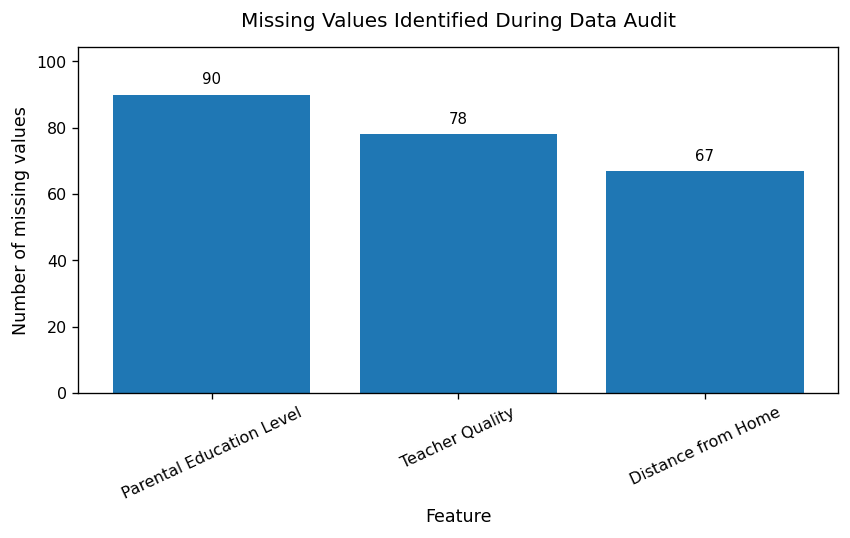

In [ ]:
EXPECTED_COLUMNS = [
    'Hours_Studied', 'Attendance', 'Parental_Involvement',
    'Access_to_Resources', 'Extracurricular_Activities',
    'Sleep_Hours', 'Previous_Scores', 'Motivation_Level',
    'Internet_Access', 'Tutoring_Sessions', 'Family_Income',
    'Teacher_Quality', 'School_Type', 'Peer_Influence',
    'Physical_Activity', 'Learning_Disabilities',
    'Parental_Education_Level', 'Distance_from_Home',
    'Gender', 'Exam_Score'
]

missing_schema = sorted(set(EXPECTED_COLUMNS) - set(df.columns))
unexpected_schema = sorted(set(df.columns) - set(EXPECTED_COLUMNS))
if missing_schema:
    raise ValueError(f'Required columns missing from dataset: {missing_schema}')

audit = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing': df.isna().sum(),
    'missing_pct': df.isna().mean() * 100,
    'nunique': df.nunique(dropna=True)
})

numeric_df = df.select_dtypes(include=np.number)
non_finite = int((~np.isfinite(numeric_df.to_numpy())).sum())

summary = pd.DataFrame([{
    'rows': len(df),
    'columns': df.shape[1],
    'duplicates': int(df.duplicated().sum()),
    'non_finite_numeric_values': non_finite,
    'unexpected_columns': ', '.join(unexpected_schema) if unexpected_schema else 'None',
    'exam_min': df['Exam_Score'].min(),
    'exam_max': df['Exam_Score'].max(),
    'exam_mean': df['Exam_Score'].mean(),
    'exam_median': df['Exam_Score'].median(),
    'exam_scores_above_100': int((df['Exam_Score'] > 100).sum())
}])

display(summary)
display(audit)
summary.to_csv(EVIDENCE_DIR / 'dataset_summary.csv', index=False)
audit.to_csv(EVIDENCE_DIR / 'data_audit.csv')

missing_only = df.isna().sum()
missing_only = missing_only[missing_only > 0].sort_values(ascending=False)
print('Columns containing missing values:')
display(missing_only.to_frame('Missing values'))

if len(missing_only):
    fig, ax = plt.subplots(figsize=(7.2, 4.6))
    bars = ax.bar([pretty_name(x) for x in missing_only.index], missing_only.values)
    ax.set_ylabel('Number of missing values')
    ax.set_xlabel('Feature')
    ax.set_title('Missing Values Identified During Data Audit', pad=12)
    ax.tick_params(axis='x', rotation=25)
    for bar, value in zip(bars, missing_only.values):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            value + max(missing_only.values)*0.025,
            str(int(value)),
            ha='center', va='bottom', fontsize=9
        )
    ax.set_ylim(0, max(missing_only.values)*1.16)
    save_figure(fig, '01_missing_values_audit.png')

## 4. Exploratory data analysis
EDA establishes the score distribution, numerical associations and the class-design problem before the supervised-learning pipeline is built.

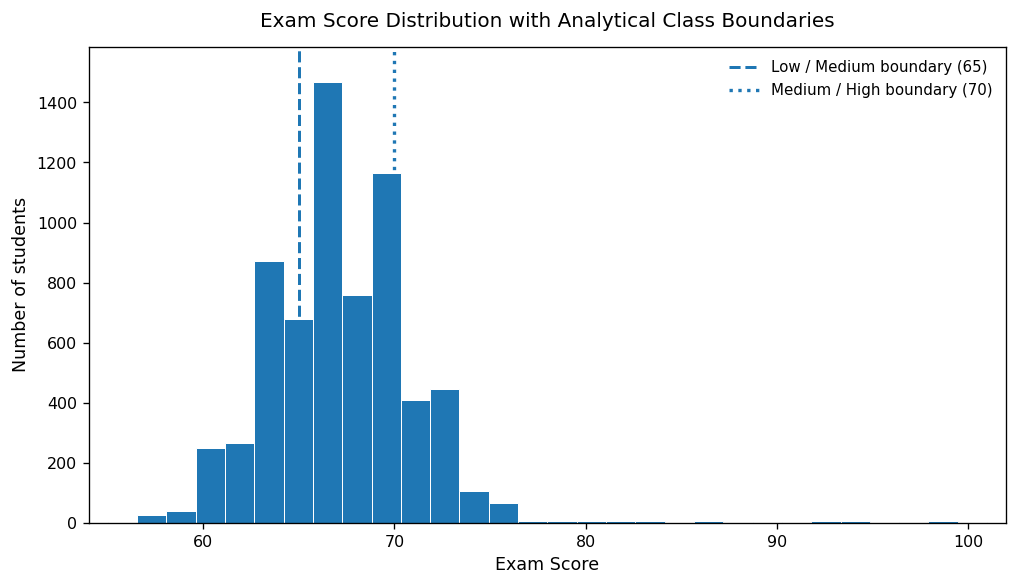

,Exam_Score
Attendance,0.581072
Hours_Studied,0.445455
Previous_Scores,0.175079
Tutoring_Sessions,0.156525
Physical_Activity,0.027824
Sleep_Hours,-0.017022


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


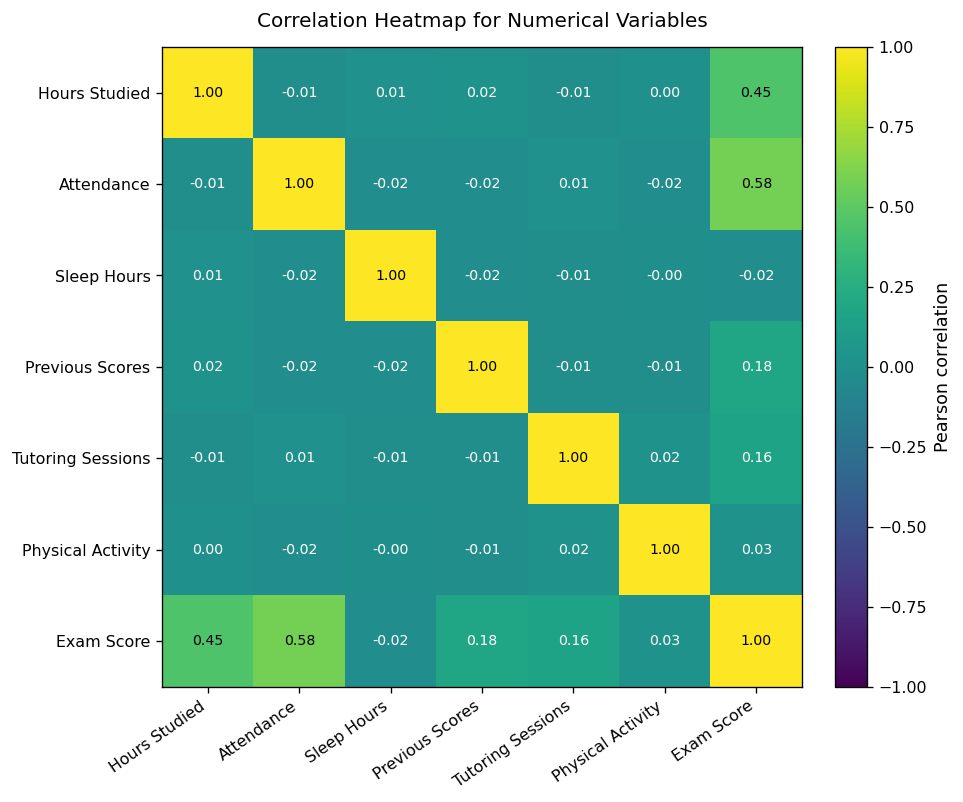

In [ ]:
fig, ax = plt.subplots(figsize=(8.6, 5.0))
ax.hist(df['Exam_Score'], bins=30, edgecolor='white', linewidth=0.6)
ax.axvline(65, linestyle='--', linewidth=1.8, label='Low / Medium boundary (65)')
ax.axvline(70, linestyle=':', linewidth=2.0, label='Medium / High boundary (70)')
ax.set_xlabel('Exam Score')
ax.set_ylabel('Number of students')
ax.set_title('Exam Score Distribution with Analytical Class Boundaries', pad=12)
ax.legend(frameon=False, loc='upper right')
ax.set_xlim(df['Exam_Score'].min() - 1, df['Exam_Score'].max() + 1)
ax.margins(y=0.08)
save_figure(fig, '02_exam_score_distribution.png')

num_cols_for_corr = df.select_dtypes(include=np.number).columns.tolist()
corr = df[num_cols_for_corr].corr()
exam_corr = (
    corr[['Exam_Score']]
    .drop(index='Exam_Score')
    .sort_values('Exam_Score', ascending=False)
)
display(exam_corr)
exam_corr.to_csv(EVIDENCE_DIR / 'exam_score_correlations.csv')

fig, ax = plt.subplots(figsize=(8.4, 6.8))
img = ax.imshow(corr, aspect='equal', vmin=-1, vmax=1)
cbar = fig.colorbar(img, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Pearson correlation')
labels = [pretty_name(c) for c in num_cols_for_corr]
ax.set_xticks(range(len(labels)), labels=labels, rotation=35, ha='right')
ax.set_yticks(range(len(labels)), labels=labels)
ax.set_title('Correlation Heatmap for Numerical Variables', pad=12)

for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        value = corr.iloc[i, j]
        rgba = img.cmap(img.norm(value))
        luminance = 0.2126*rgba[0] + 0.7152*rgba[1] + 0.0722*rgba[2]
        text_colour = 'black' if luminance > 0.55 else 'white'
        ax.text(j, i, f'{value:.2f}', ha='center', va='center',
                fontsize=8.5, color=text_colour)

save_figure(fig, '05_correlation_heatmap.png')

## 5. Target engineering and sensitivity analysis
The assessment requires a classification target, while the source dataset provides a continuous `Exam_Score`. The target is therefore engineered explicitly and `Exam_Score` is excluded from all predictors to prevent direct target leakage.

,Count,Percent
Performance_Class,,
Low,1452,21.976691
Medium,3530,53.428182
High,1625,24.595126


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


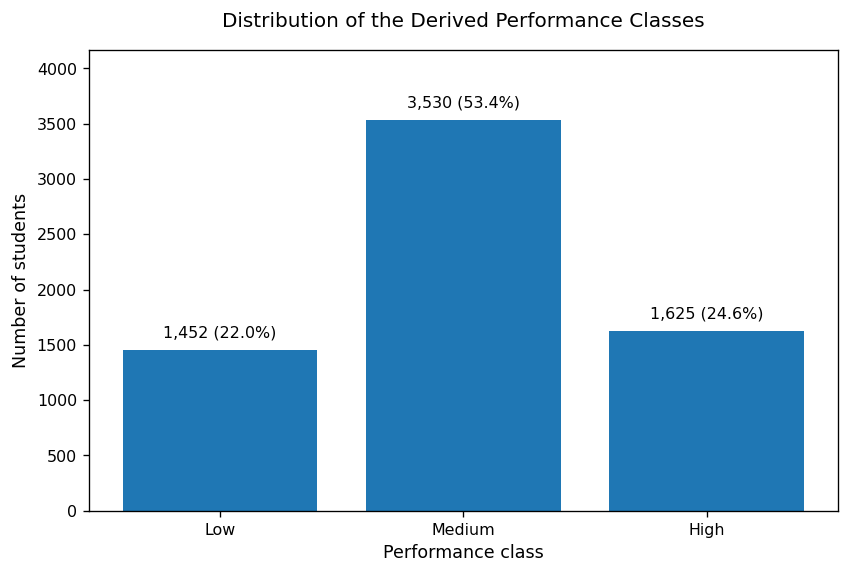

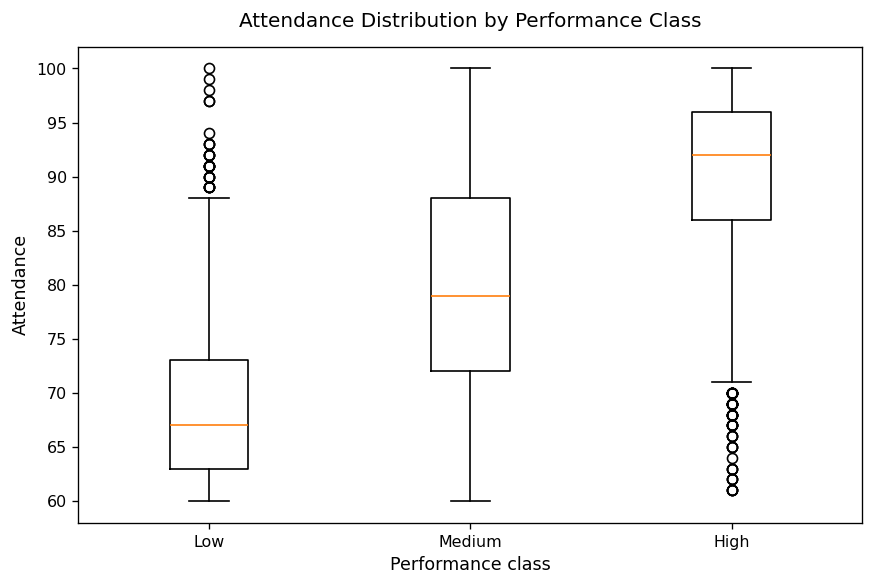

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
def make_target(data, low_cut=65, high_cut=70):
    return np.select(
        [data['Exam_Score'] < low_cut, data['Exam_Score'] < high_cut],
        ['Low', 'Medium'],
        default='High'
    )

df['Performance_Class'] = make_target(df, 65, 70)

class_dist = df['Performance_Class'].value_counts().reindex(['Low', 'Medium', 'High'])
class_table = pd.DataFrame({
    'Count': class_dist,
    'Percent': class_dist / len(df) * 100
})
display(class_table)
class_table.to_csv(EVIDENCE_DIR / 'target_class_distribution.csv')

fig, ax = plt.subplots(figsize=(7.2, 4.9))
bars = ax.bar(class_table.index, class_table['Count'])
max_count = class_table['Count'].max()
ax.set_ylim(0, max_count * 1.18)
for bar, n, p in zip(bars, class_table['Count'], class_table['Percent']):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + max_count*0.025,
        f'{int(n):,} ({p:.1f}%)',
        ha='center', va='bottom', fontsize=9.5
    )
ax.set_ylabel('Number of students')
ax.set_xlabel('Performance class')
ax.set_title('Distribution of the Derived Performance Classes', pad=14)
save_figure(fig, '03_target_distribution.png')

box_data = [
    df.loc[df['Performance_Class'] == cls, 'Attendance'].dropna().to_numpy()
    for cls in ['Low', 'Medium', 'High']
]
fig, ax = plt.subplots(figsize=(7.4, 5.0))
ax.boxplot(box_data, tick_labels=['Low', 'Medium', 'High'], showfliers=True)
ax.set_xlabel('Performance class')
ax.set_ylabel('Attendance')
ax.set_title('Attendance Distribution by Performance Class', pad=12)
save_figure(fig, '04_attendance_boxplot.png')

### 5.1 Target-boundary sensitivity

Nearby class definitions are checked with a baseline Logistic Regression configuration (`C=1.0`) using training-only five-fold cross-validation. The sensitivity check therefore evaluates the target definition independently of the later hyperparameter search.

In [ ]:
X_all = df.drop(columns=['Exam_Score','Performance_Class'])
num_cols = X_all.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_all.select_dtypes(exclude=np.number).columns.tolist()

def make_ohe():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)

def make_preprocessor(data):
    nums = data.select_dtypes(include=np.number).columns.tolist()
    cats = data.select_dtypes(exclude=np.number).columns.tolist()
    return ColumnTransformer([
        ('num', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), nums),
        ('cat', Pipeline([('impute', SimpleImputer(strategy='most_frequent')), ('onehot', make_ohe())]), cats)
    ])

schemes = [(64,70),(65,70),(66,70),(65,71)]
sens_rows=[]
for low_cut, high_cut in schemes:
    labels = make_target(df, low_cut, high_cut)
    le_tmp = LabelEncoder().fit(labels)
    y_tmp = le_tmp.transform(labels)
    idx = np.arange(len(df))
    train_i, _ = train_test_split(idx, test_size=0.20, random_state=RANDOM_STATE, stratify=y_tmp)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    pipe = Pipeline([
        ('preprocess', make_preprocessor(X_all)),
        ('model', LogisticRegression(C=1.0, max_iter=5000, random_state=RANDOM_STATE))
    ])
    scores = cross_val_score(pipe, X_all.iloc[train_i], y_tmp[train_i], cv=cv, scoring='f1_macro', n_jobs=-1)
    counts = pd.Series(labels).value_counts()
    sens_rows.append({
        'Low_Cut': low_cut, 'High_Cut': high_cut,
        'Low_n': counts.get('Low',0), 'Medium_n': counts.get('Medium',0), 'High_n': counts.get('High',0),
        'CV_Macro_F1_Mean': scores.mean(), 'CV_Macro_F1_SD': scores.std()
    })

target_sensitivity = pd.DataFrame(sens_rows)
display(target_sensitivity)
target_sensitivity.to_csv(EVIDENCE_DIR / 'target_sensitivity.csv', index=False)

,Low_Cut,High_Cut,Low_n,Medium_n,High_n,CV_Macro_F1_Mean,CV_Macro_F1_SD
0,64,70,951,4031,1625,0.961377,0.003521
1,65,70,1452,3530,1625,0.962451,0.004293
2,66,70,2131,2851,1625,0.962879,0.003883
3,65,71,1452,4072,1083,0.961912,0.004133


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 6. Train/test design and leakage controls
An 80/20 stratified split creates a final held-out test set. All imputing, encoding and scaling are fitted inside pipelines, so validation and test observations cannot influence preprocessing parameters.

Encoded classes: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}
Training rows: 5285
Test rows: 1322
Numerical predictors: ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']
Categorical predictors: ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Partition,Rows,Percent
0,Training,5285,79.990919
1,Test,1322,20.009081


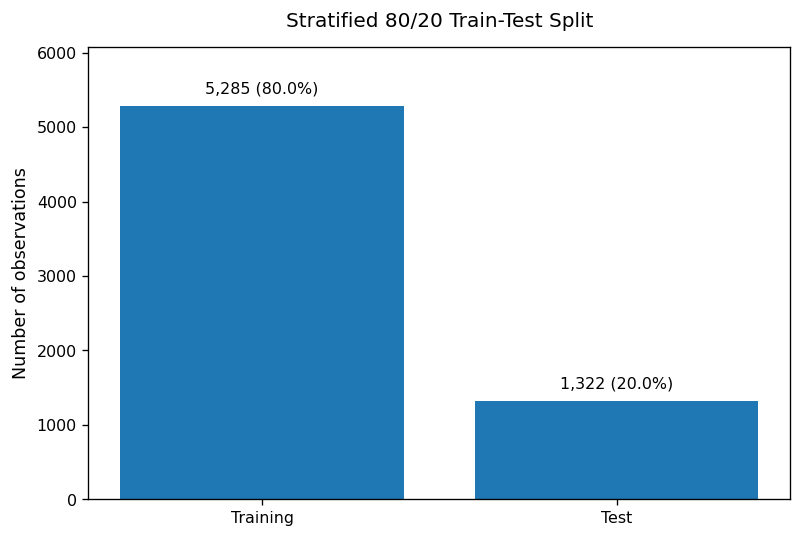

In [ ]:
X = df.drop(columns=['Exam_Score', 'Performance_Class'])

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['Performance_Class'])
print(
    'Encoded classes:',
    dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
)

idx = np.arange(len(df))
train_idx, test_idx = train_test_split(
    idx, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()
y_train = y[train_idx]
y_test = y[test_idx]

preprocessor = make_preprocessor(X)
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print('Training rows:', len(X_train))
print('Test rows:', len(X_test))
print('Numerical predictors:', X.select_dtypes(include=np.number).columns.tolist())
print('Categorical predictors:', X.select_dtypes(exclude=np.number).columns.tolist())

split_table = pd.DataFrame({
    'Partition': ['Training', 'Test'],
    'Rows': [len(X_train), len(X_test)],
    'Percent': [len(X_train)/len(df)*100, len(X_test)/len(df)*100]
})
display(split_table)
split_table.to_csv(EVIDENCE_DIR / 'train_test_split.csv', index=False)

fig, ax = plt.subplots(figsize=(6.8, 4.6))
bars = ax.bar(split_table['Partition'], split_table['Rows'])
ax.set_ylabel('Number of observations')
ax.set_title('Stratified 80/20 Train-Test Split', pad=12)
ax.set_ylim(0, split_table['Rows'].max()*1.15)
for bar, rows, pct in zip(bars, split_table['Rows'], split_table['Percent']):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + split_table['Rows'].max()*0.025,
        f'{rows:,} ({pct:.1f}%)',
        ha='center', va='bottom', fontsize=9.5
    )
save_figure(fig, '06_train_test_split.png')

## 7. Baseline and candidate-model comparison
A majority-class `DummyClassifier` establishes a non-learning benchmark. Five distinct supervised model families are then evaluated under the same five-fold stratified cross-validation design. Macro-F1 is the principal comparison metric because each performance class matters and the class sizes are unequal.

,Model,CV_Accuracy_Mean,CV_Accuracy_SD,CV_Balanced_Accuracy_Mean,CV_Balanced_Accuracy_SD,CV_Macro_F1_Mean,CV_Macro_F1_SD
1,Logistic Regression,0.964617,0.003765,0.957056,0.006347,0.962451,0.004293
5,MLP Neural Network,0.945885,0.005298,0.940376,0.008613,0.943177,0.006214
4,SVM (RBF),0.934721,0.004315,0.923592,0.004998,0.931322,0.005054
3,Random Forest,0.815326,0.007115,0.745081,0.010977,0.788533,0.009403
2,Decision Tree,0.727909,0.017245,0.727129,0.021051,0.721330,0.018192
0,Dummy (most frequent),0.534342,0.000378,0.333333,0.000000,0.232170,0.000107


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


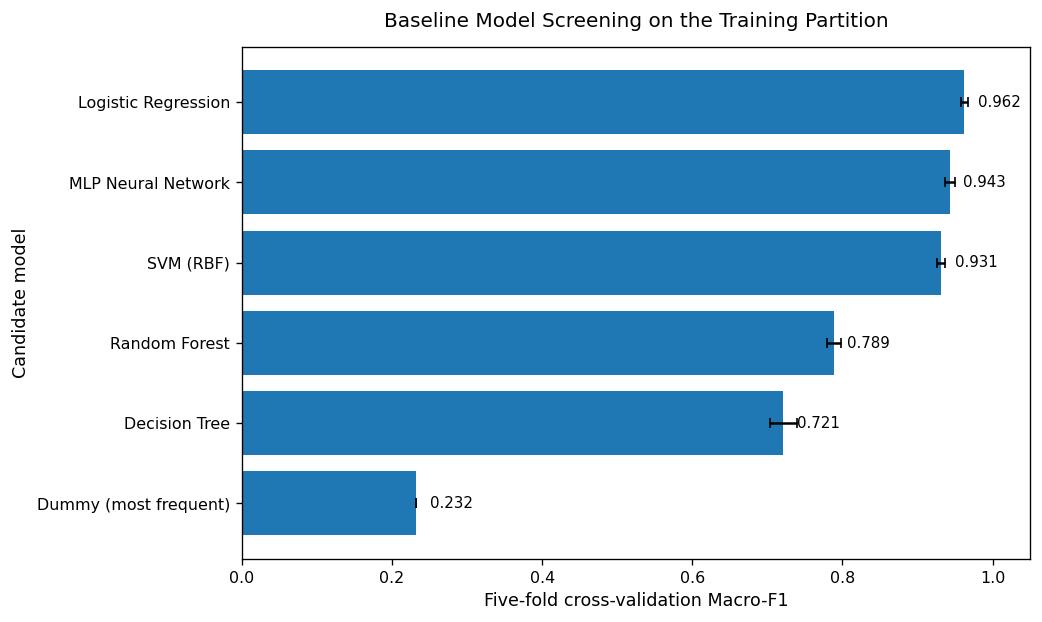

In [ ]:
models = {
    'Dummy (most frequent)': DummyClassifier(strategy='most_frequent'),
    'Logistic Regression': LogisticRegression(max_iter=3000, random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(min_samples_leaf=4, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=300, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1),
    'SVM (RBF)': SVC(C=2, kernel='rbf', probability=False, random_state=RANDOM_STATE),
    'MLP Neural Network': MLPClassifier(hidden_layer_sizes=(64,32), alpha=0.001, max_iter=800, random_state=RANDOM_STATE)
}

scoring = {'accuracy':'accuracy','balanced_accuracy':'balanced_accuracy','macro_f1':'f1_macro'}
rows=[]
for name, model in models.items():
    pipe = Pipeline([('preprocess', preprocessor), ('model', model)])
    scores = cross_validate(pipe, X_train, y_train, cv=cv5, scoring=scoring, n_jobs=-1)
    rows.append({
        'Model': name,
        'CV_Accuracy_Mean': scores['test_accuracy'].mean(),
        'CV_Accuracy_SD': scores['test_accuracy'].std(),
        'CV_Balanced_Accuracy_Mean': scores['test_balanced_accuracy'].mean(),
        'CV_Balanced_Accuracy_SD': scores['test_balanced_accuracy'].std(),
        'CV_Macro_F1_Mean': scores['test_macro_f1'].mean(),
        'CV_Macro_F1_SD': scores['test_macro_f1'].std()
    })

screening = pd.DataFrame(rows).sort_values('CV_Macro_F1_Mean', ascending=False)
display(screening)
screening.to_csv(EVIDENCE_DIR / 'model_screening_5fold.csv', index=False)



plot_df = screening.sort_values('CV_Macro_F1_Mean')
fig, ax = plt.subplots(figsize=(8.8, 5.3))
bars = ax.barh(
    plot_df['Model'],
    plot_df['CV_Macro_F1_Mean'],
    xerr=plot_df['CV_Macro_F1_SD'],
    capsize=3
)
ax.set_xlim(0, 1.05)
ax.set_xlabel('Five-fold cross-validation Macro-F1')
ax.set_ylabel('Candidate model')
ax.set_title('Baseline Model Screening on the Training Partition', pad=12)

for bar, value in zip(bars, plot_df['CV_Macro_F1_Mean']):
    ax.text(
        min(value + 0.018, 1.015),
        bar.get_y() + bar.get_height() / 2,
        f'{value:.3f}',
        va='center',
        ha='left',
        fontsize=9
    )

save_figure(fig, '07_model_comparison.png')

## 8. Preprocessing ablation experiments
The project tests whether additional feature engineering, feature selection or class balancing improves validation performance. Techniques are retained only when evidence supports them.

In [ ]:
# 8.1 Feature engineering: study-hours x attendance interaction
X_interaction = X.copy()
X_interaction['Study_Attendance_Interaction'] = X_interaction['Hours_Studied'] * X_interaction['Attendance'] / 100
fe_rows=[]
for design, data in [('Original predictors', X), ('+ Study x Attendance interaction', X_interaction)]:
    pipe = Pipeline([
        ('preprocess', make_preprocessor(data)),
        ('model', LogisticRegression(C=100, max_iter=5000, random_state=RANDOM_STATE))
    ])
    scores = cross_val_score(pipe, data.iloc[train_idx], y_train, cv=cv5, scoring='f1_macro', n_jobs=-1)
    fe_rows.append({'Design':design,'CV_Macro_F1_Mean':scores.mean(),'CV_Macro_F1_SD':scores.std()})
feature_engineering = pd.DataFrame(fe_rows)
display(feature_engineering)
feature_engineering.to_csv(EVIDENCE_DIR / 'feature_engineering_ablation.csv', index=False)

# 8.2 Feature-selection ablation
fs_rows=[]
for pct in [50,75,100]:
    steps=[('preprocess', preprocessor)]
    if pct < 100:
        steps.append(('select', SelectPercentile(score_func=f_classif, percentile=pct)))
    steps.append(('model', LogisticRegression(C=100, max_iter=5000, random_state=RANDOM_STATE)))
    scores = cross_val_score(Pipeline(steps), X_train, y_train, cv=cv5, scoring='f1_macro', n_jobs=-1)
    fs_rows.append({'Features_Retained_Pct':pct,'CV_Macro_F1_Mean':scores.mean(),'CV_Macro_F1_SD':scores.std()})
feature_selection = pd.DataFrame(fs_rows)
display(feature_selection)
feature_selection.to_csv(EVIDENCE_DIR / 'feature_selection_ablation.csv', index=False)

,Design,CV_Macro_F1_Mean,CV_Macro_F1_SD
0,Original predictors,0.963591,0.004006
1,+ Study x Attendance interaction,0.957343,0.004389


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Features_Retained_Pct,CV_Macro_F1_Mean,CV_Macro_F1_SD
0,50,0.907092,0.007400
1,75,0.963252,0.003117
2,100,0.963591,0.004006


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### 8.3 Class-imbalance ablation
Class weighting, random over/under-sampling and SMOTENC are compared with no resampling. This avoids assuming that synthetic balancing must improve a moderately imbalanced three-class dataset.

,Strategy,CV_Macro_F1_Mean,CV_Macro_F1_SD
0,No resampling,0.963591,0.004006
2,Random oversampling,0.946528,0.009827
1,Class weighting,0.945437,0.006790
3,Random undersampling,0.942139,0.006203
4,SMOTENC,0.938377,0.004746


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


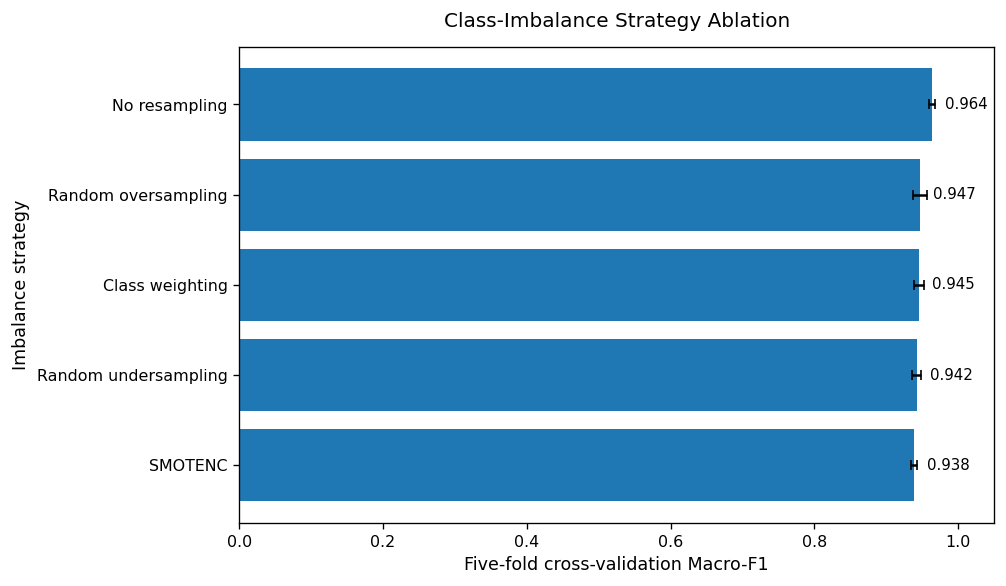

In [ ]:
imbalance_rows=[]
def evaluate_strategy(name, pipeline):
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv5, scoring='f1_macro', n_jobs=-1)
    imbalance_rows.append({'Strategy':name,'CV_Macro_F1_Mean':scores.mean(),'CV_Macro_F1_SD':scores.std()})

base_lr = LogisticRegression(C=100, max_iter=5000, random_state=RANDOM_STATE)
evaluate_strategy('No resampling', Pipeline([('preprocess',preprocessor),('model',base_lr)]))
evaluate_strategy('Class weighting', Pipeline([('preprocess',preprocessor),('model',LogisticRegression(C=100,max_iter=5000,class_weight='balanced',random_state=RANDOM_STATE))]))
evaluate_strategy('Random oversampling', ImbPipeline([('preprocess',preprocessor),('sampler',RandomOverSampler(random_state=RANDOM_STATE)),('model',base_lr)]))
evaluate_strategy('Random undersampling', ImbPipeline([('preprocess',preprocessor),('sampler',RandomUnderSampler(random_state=RANDOM_STATE)),('model',base_lr)]))

numeric_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X.select_dtypes(exclude=np.number).columns.tolist()
pre_smote = ColumnTransformer([
    ('num', Pipeline([('impute', SimpleImputer(strategy='median'))]), numeric_cols),
    ('cat', Pipeline([('impute', SimpleImputer(strategy='most_frequent')),('ordinal',OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1))]), categorical_cols)
])
num_n, cat_n = len(numeric_cols), len(categorical_cols)
post_smote = ColumnTransformer([
    ('num', StandardScaler(), list(range(num_n))),
    ('cat', make_ohe(), list(range(num_n, num_n+cat_n)))
])
evaluate_strategy('SMOTENC', ImbPipeline([
    ('pre_encode', pre_smote),
    ('sampler', SMOTENC(categorical_features=[False]*num_n+[True]*cat_n, random_state=RANDOM_STATE)),
    ('postprocess', post_smote),
    ('model', base_lr)
]))

imbalance = pd.DataFrame(imbalance_rows).sort_values('CV_Macro_F1_Mean', ascending=False)
display(imbalance)
imbalance.to_csv(EVIDENCE_DIR / 'imbalance_ablation.csv', index=False)



plot_df = imbalance.sort_values('CV_Macro_F1_Mean')
fig, ax = plt.subplots(figsize=(8.5, 5.0))
bars = ax.barh(
    plot_df['Strategy'],
    plot_df['CV_Macro_F1_Mean'],
    xerr=plot_df['CV_Macro_F1_SD'],
    capsize=3
)

# Full 0–1 metric scale avoids exaggerating small score differences.
ax.set_xlim(0, 1.05)
ax.set_xlabel('Five-fold cross-validation Macro-F1')
ax.set_ylabel('Imbalance strategy')
ax.set_title('Class-Imbalance Strategy Ablation', pad=12)

for bar, value in zip(bars, plot_df['CV_Macro_F1_Mean']):
    ax.text(
        min(value + 0.018, 1.015),
        bar.get_y() + bar.get_height() / 2,
        f'{value:.3f}',
        va='center',
        ha='left',
        fontsize=9
    )

save_figure(fig, '08_imbalance_ablation.png')

## 9. Hyperparameter tuning and final model selection
Logistic Regression is the strongest model family in cross-validation, so its regularisation strength and class weighting are tuned using **training data only**. The held-out test set remains untouched until the next section.

In [ ]:
logistic_search = GridSearchCV(
    Pipeline([
        ('preprocess', preprocessor),
        ('model', LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))
    ]),
    param_grid={
        'model__C':[0.5,1,2,5,10,20,50,100],
        'model__class_weight':[None,'balanced']
    },
    scoring='f1_macro', cv=cv5, refit=True, n_jobs=-1
)
logistic_search.fit(X_train, y_train)
print('Best parameters:', logistic_search.best_params_)
print('Best five-fold CV macro-F1:', logistic_search.best_score_)

search_results = pd.DataFrame(logistic_search.cv_results_).sort_values('rank_test_score')
display(search_results[['param_model__C','param_model__class_weight','mean_test_score','std_test_score','rank_test_score']].head(12))
search_results.to_csv(EVIDENCE_DIR / 'grid_logistic_regression.csv', index=False)

best_model = logistic_search.best_estimator_

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(


Best parameters: {'model__C': 100, 'model__class_weight': None}
Best five-fold CV macro-F1: 0.9635913599589594


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,param_model__C,param_model__class_weight,mean_test_score,std_test_score,rank_test_score
14,100.0,None,0.963591,0.004006,1
8,10.0,None,0.963208,0.004138,2
10,20.0,None,0.963206,0.004002,3
12,50.0,None,0.963206,0.004002,3
4,2.0,None,0.962731,0.004363,5
2,1.0,None,0.962451,0.004293,6
6,5.0,None,0.962387,0.004102,7
0,0.5,None,0.960705,0.004800,8
11,20.0,balanced,0.945870,0.007138,9
9,10.0,balanced,0.945475,0.006824,10


## 10. Final held-out prediction and proof of performance
The selected pipeline is evaluated once on the untouched 20% test partition. This is the principal evidence of generalisation to unseen observations from the supplied dataset.

,Accuracy,Balanced_Accuracy,Macro_Precision,Macro_Recall,Macro_F1,Macro_ROC_AUC_OVR
0,0.96823,0.964461,0.96912,0.964461,0.966752,0.993931


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,precision,recall,f1-score,support
Low,0.972222,0.962199,0.967185,291.00000
Medium,0.966387,0.977337,0.971831,706.00000
High,0.968750,0.953846,0.961240,325.00000
accuracy,0.968230,0.968230,0.968230,0.96823
macro avg,0.969120,0.964461,0.966752,1322.00000
weighted avg,0.968252,0.968230,0.968205,1322.00000


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Low,Medium,High
Low,280,11,0
Medium,6,690,10
High,2,13,310


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


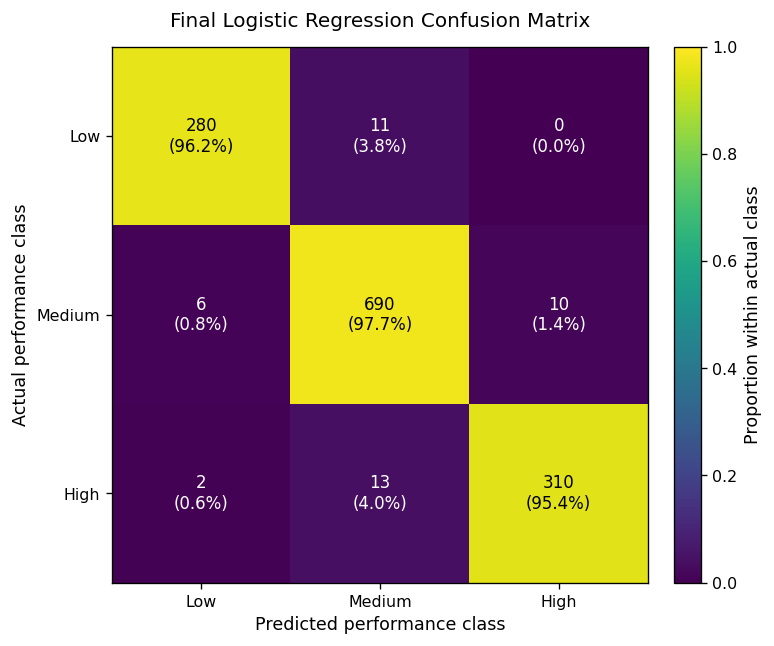

In [ ]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)

p,r,f,_ = precision_recall_fscore_support(y_test, y_pred, average='macro', zero_division=0)
metrics = pd.DataFrame([{
    'Accuracy': accuracy_score(y_test,y_pred),
    'Balanced_Accuracy': balanced_accuracy_score(y_test,y_pred),
    'Macro_Precision': p, 'Macro_Recall': r, 'Macro_F1': f,
    'Macro_ROC_AUC_OVR': roc_auc_score(y_test,y_proba,multi_class='ovr',average='macro')
}])
display(metrics)
metrics.to_csv(EVIDENCE_DIR / 'final_metrics.csv', index=False)

DISPLAY_ORDER = ['Low','Medium','High']
DISPLAY_CODES = [int(label_encoder.transform([c])[0]) for c in DISPLAY_ORDER]
report_dict = classification_report(y_test,y_pred,labels=DISPLAY_CODES,target_names=DISPLAY_ORDER,output_dict=True,zero_division=0)
report_df = pd.DataFrame(report_dict).T
display(report_df)
report_df.to_csv(EVIDENCE_DIR / 'classification_report.csv')

cm = confusion_matrix(y_test,y_pred,labels=DISPLAY_CODES)
cm_df = pd.DataFrame(cm,index=DISPLAY_ORDER,columns=DISPLAY_ORDER)
display(cm_df)
cm_df.to_csv(EVIDENCE_DIR / 'confusion_matrix.csv')



# Colour represents the row-normalised proportion; labels show count and percentage.
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(6.6, 5.5))
img = ax.imshow(cm_norm, vmin=0, vmax=1)
cbar = fig.colorbar(img, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Proportion within actual class')

ax.set_xticks(range(3), labels=DISPLAY_ORDER)
ax.set_yticks(range(3), labels=DISPLAY_ORDER)
ax.set_xlabel('Predicted performance class')
ax.set_ylabel('Actual performance class')
ax.set_title('Final Logistic Regression Confusion Matrix', pad=12)

for i in range(3):
    for j in range(3):
        value = cm_norm[i, j]
        rgba = img.cmap(img.norm(value))
        luminance = 0.2126 * rgba[0] + 0.7152 * rgba[1] + 0.0722 * rgba[2]
        text_colour = 'black' if luminance > 0.55 else 'white'
        ax.text(
            j, i,
            f'{cm[i, j]:,}\n({value * 100:.1f}%)',
            ha='center',
            va='center',
            fontsize=10,
            color=text_colour
        )

save_figure(fig, '09_confusion_matrix.png')

### 10.1 Record-level prediction evidence
The following table shows actual and predicted classes with class probabilities for held-out students. It demonstrates the prediction output beyond aggregate metrics.

In [ ]:
prediction_evidence = X_test.reset_index(drop=True).copy()
prediction_evidence['Actual_Class'] = label_encoder.inverse_transform(y_test)
prediction_evidence['Predicted_Class'] = label_encoder.inverse_transform(y_pred)
for class_name in DISPLAY_ORDER:
    code_i = int(label_encoder.transform([class_name])[0])
    prediction_evidence[f'P_{class_name}'] = y_proba[:,code_i]
prediction_evidence['Correct'] = prediction_evidence['Actual_Class'] == prediction_evidence['Predicted_Class']

display(prediction_evidence[['Hours_Studied','Attendance','Previous_Scores','Actual_Class','Predicted_Class','P_Low','P_Medium','P_High','Correct']].head(20))
prediction_evidence.to_csv(EVIDENCE_DIR / 'heldout_record_level_predictions.csv', index=False)

,Hours_Studied,Attendance,Previous_Scores,Actual_Class,Predicted_Class,P_Low,P_Medium,P_High,Correct
0,29,93,93,High,High,3.052712e-24,0.000037,9.999627e-01,True
1,28,89,75,Medium,Medium,5.955799e-09,0.939791,6.020879e-02,True
2,23,70,75,Medium,Medium,4.192730e-03,0.995631,1.760242e-04,True
3,19,76,66,Medium,Medium,8.245562e-04,0.998549,6.261701e-04,True
4,24,63,99,Medium,Medium,2.073583e-03,0.997521,4.049616e-04,True
5,28,62,64,Medium,Medium,9.485800e-02,0.905085,5.713447e-05,True
6,15,65,93,Low,Low,9.519843e-01,0.048016,1.077980e-07,True
7,23,91,62,High,High,1.150945e-13,0.106067,8.939327e-01,True
8,14,94,85,Medium,Medium,1.847418e-03,0.997909,2.437867e-04,True
9,37,96,77,High,High,6.268265e-28,0.000002,9.999977e-01,True


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 11. Error analysis and ROC-AUC
Error analysis checks whether mistakes are systematic. One-v-rest ROC curves assess ranking performance for each class.

Total held-out errors: 42
Boundary-adjacent errors: 37 (88.1%)


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Exam_Score,Performance_Class,Predicted,Correct,Boundary_Adjacent
2324,70,High,Medium,False,True
888,64,Low,Medium,False,True
751,64,Low,Medium,False,True
3403,65,Medium,Low,False,True
6209,69,Medium,High,False,True
4118,65,Medium,Low,False,True
5363,64,Low,Medium,False,True
5651,65,Medium,Low,False,True
5971,70,High,Medium,False,True
5430,69,Medium,High,False,True


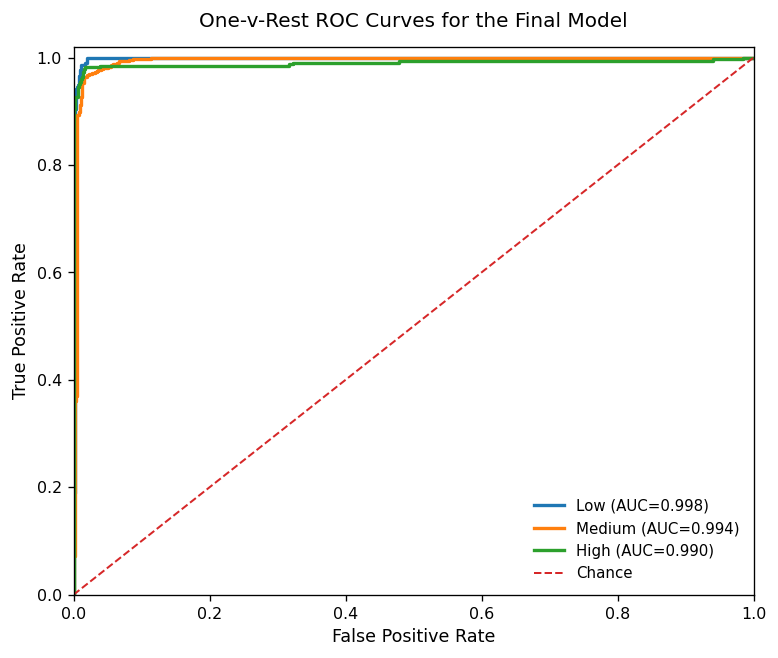

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Class,AUC
0,Low,0.997687
1,Medium,0.994208
2,High,0.989899


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
test_diag = df.iloc[test_idx][['Exam_Score','Performance_Class']].copy()
test_diag['Predicted'] = label_encoder.inverse_transform(y_pred)
test_diag['Correct'] = test_diag['Performance_Class'] == test_diag['Predicted']
errors = test_diag.loc[~test_diag['Correct']].copy()
errors['Boundary_Adjacent'] = errors['Exam_Score'].isin([64,65,69,70])
print('Total held-out errors:', len(errors))
print('Boundary-adjacent errors:', int(errors['Boundary_Adjacent'].sum()), f"({errors['Boundary_Adjacent'].mean()*100:.1f}%)")
display(errors.head(30))
errors.to_csv(EVIDENCE_DIR / 'heldout_errors.csv', index=False)



y_bin = label_binarize(y_test, classes=range(len(label_encoder.classes_)))
fig, ax = plt.subplots(figsize=(6.6, 5.6))
roc_rows = []

for class_name in DISPLAY_ORDER:
    code_i = int(label_encoder.transform([class_name])[0])
    fpr, tpr, _ = roc_curve(y_bin[:, code_i], y_proba[:, code_i])
    class_auc = auc(fpr, tpr)
    roc_rows.append({'Class': class_name, 'AUC': class_auc})
    ax.plot(fpr, tpr, linewidth=2, label=f'{class_name} (AUC={class_auc:.3f})')

ax.plot([0, 1], [0, 1], linestyle='--', linewidth=1.2, label='Chance')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('One-v-Rest ROC Curves for the Final Model', pad=12)
ax.legend(frameon=False, loc='lower right')
save_figure(fig, '10_roc_curves.png')

roc_df = pd.DataFrame(roc_rows)
display(roc_df)
roc_df.to_csv(EVIDENCE_DIR / 'class_auc.csv', index=False)

## 12. Explainability: feature importance and coefficient direction
Permutation importance measures the loss in held-out macro-F1 when each original predictor is shuffled. Logistic Regression coefficients are also exported to show directional associations after transformation. Neither measure establishes causality.

,Feature,Mean,SD
1,Attendance,0.470950,0.014325
0,Hours_Studied,0.355898,0.015269
3,Access_to_Resources,0.125953,0.006711
6,Previous_Scores,0.125123,0.008669
2,Parental_Involvement,0.116465,0.006800
9,Tutoring_Sessions,0.101005,0.004912
16,Parental_Education_Level,0.054212,0.004893
7,Motivation_Level,0.053446,0.004758
13,Peer_Influence,0.052888,0.003064
10,Family_Income,0.046023,0.002969


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


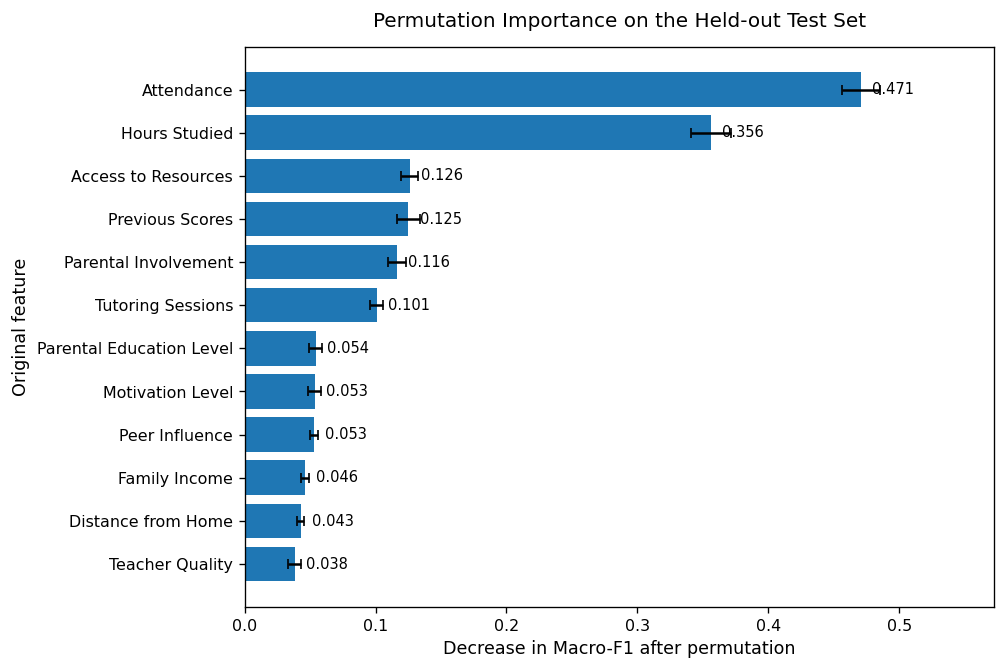


Largest positive coefficients for Low


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Class,Feature,Coefficient
50,Low,cat__Access_to_Resources_Low,3.851928
47,Low,cat__Parental_Involvement_Low,3.805519
55,Low,cat__Motivation_Level_Low,1.980987
63,Low,cat__Teacher_Quality_Low,1.944247
67,Low,cat__Peer_Influence_Negative,1.897777
60,Low,cat__Family_Income_Low,1.838862
75,Low,cat__Distance_from_Home_Far,1.805930
57,Low,cat__Internet_Access_No,1.780490
73,Low,cat__Parental_Education_Level_High School,1.751215
71,Low,cat__Learning_Disabilities_Yes,1.664512



Largest positive coefficients for High


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Class,Feature,Coefficient
1,High,num__Attendance,6.962474
0,High,num__Hours_Studied,5.431107
9,High,cat__Access_to_Resources_High,2.946007
6,High,cat__Parental_Involvement_High,2.882883
3,High,num__Previous_Scores,2.115354
4,High,num__Tutoring_Sessions,1.836894
14,High,cat__Motivation_Level_High,1.543223
22,High,cat__Teacher_Quality_High,1.452339
29,High,cat__Peer_Influence_Positive,1.426856
34,High,cat__Parental_Education_Level_Postgraduate,1.410240


In [ ]:
perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    scoring='f1_macro',
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
importance = pd.DataFrame({
    'Feature': X.columns,
    'Mean': perm.importances_mean,
    'SD': perm.importances_std
}).sort_values('Mean', ascending=False)

display(importance.head(15))
importance.to_csv(EVIDENCE_DIR / 'permutation_importance.csv', index=False)

plot_df = importance.head(12).sort_values('Mean').copy()
plot_df['Display_Feature'] = plot_df['Feature'].map(pretty_name)

fig, ax = plt.subplots(figsize=(8.5, 5.7))
bars = ax.barh(
    plot_df['Display_Feature'],
    plot_df['Mean'],
    xerr=plot_df['SD'],
    capsize=3
)
ax.set_xlabel('Decrease in Macro-F1 after permutation')
ax.set_ylabel('Original feature')
ax.set_title('Permutation Importance on the Held-out Test Set', pad=12)

right_edge = max(float((plot_df['Mean'] + plot_df['SD']).max()) * 1.18, 0.01)
left_edge = min(0.0, float(plot_df['Mean'].min()) * 1.1)
ax.set_xlim(left_edge, right_edge)

for bar, value in zip(bars, plot_df['Mean']):
    ax.text(
        value + right_edge * 0.015,
        bar.get_y() + bar.get_height() / 2,
        f'{value:.3f}',
        va='center',
        ha='left',
        fontsize=8.8
    )

save_figure(fig, '11_permutation_importance.png')

prep = best_model.named_steps['preprocess']
feature_names = prep.get_feature_names_out()
coef = best_model.named_steps['model'].coef_
coef_rows = []

for class_code, class_name in enumerate(label_encoder.classes_):
    for feat, value in zip(feature_names, coef[class_code]):
        coef_rows.append({
            'Class': class_name,
            'Feature': feat,
            'Coefficient': value
        })

coef_df = pd.DataFrame(coef_rows)
coef_df.to_csv(EVIDENCE_DIR / 'coefficients.csv', index=False)

for target in ['Low', 'High']:
    print()
    print('Largest positive coefficients for', target)
    display(
        coef_df[coef_df['Class'] == target]
        .nlargest(10, 'Coefficient')
    )

## 13. At-risk decision-threshold sensitivity

The default multiclass decision rule is retained for the reported held-out metrics. The analysis below is a post-hoc sensitivity analysis showing how a separate Low-risk review flag would trade precision against recall. No operating threshold is selected from the test set; a real deployment would require separate validation and stakeholder-defined costs for false negatives and false positives.

,Threshold,TP,FP,FN,TN,Precision,Recall,FPR
0,0.10,291,50,0,981,0.853372,1.000000,0.048497
1,0.15,291,35,0,996,0.892638,1.000000,0.033948
2,0.20,291,30,0,1001,0.906542,1.000000,0.029098
3,0.25,289,21,2,1010,0.932258,0.993127,0.020369
4,0.30,287,18,4,1013,0.940984,0.986254,0.017459
5,0.35,287,15,4,1016,0.950331,0.986254,0.014549
6,0.40,286,11,5,1020,0.962963,0.982818,0.010669
7,0.45,282,9,9,1022,0.969072,0.969072,0.008729
8,0.50,280,8,11,1023,0.972222,0.962199,0.007759
9,0.60,272,4,19,1027,0.985507,0.934708,0.003880


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


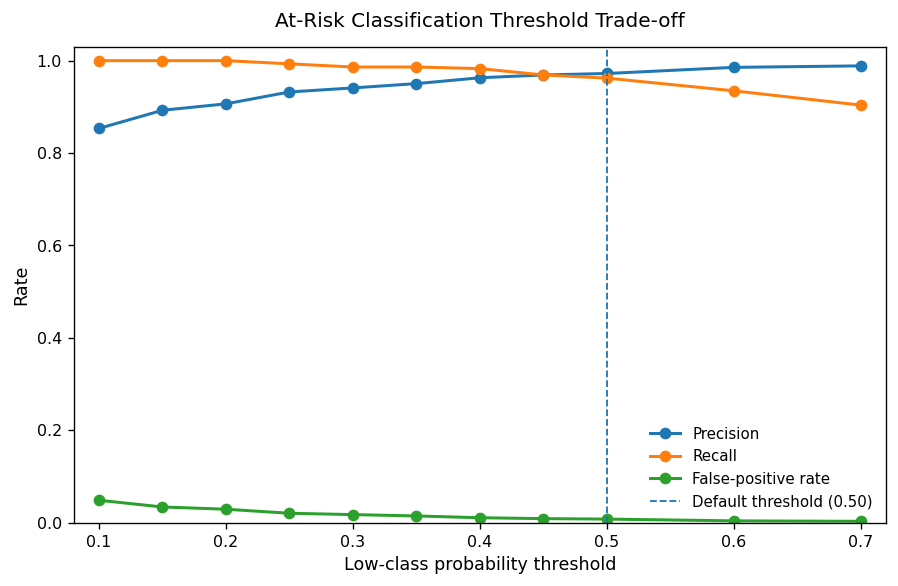

In [ ]:
low_code=int(label_encoder.transform(['Low'])[0])
low_pos=(y_test==low_code); low_prob=y_proba[:,low_code]
threshold_rows=[]
for threshold in [0.10,0.15,0.20,0.25,0.30,0.35,0.40,0.45,0.50,0.60,0.70]:
    pred_low=low_prob>=threshold
    tp=int(np.sum(pred_low & low_pos)); fp=int(np.sum(pred_low & ~low_pos))
    fn=int(np.sum(~pred_low & low_pos)); tn=int(np.sum(~pred_low & ~low_pos))
    threshold_rows.append({
        'Threshold':threshold,'TP':tp,'FP':fp,'FN':fn,'TN':tn,
        'Precision':tp/(tp+fp) if tp+fp else np.nan,
        'Recall':tp/(tp+fn) if tp+fn else np.nan,
        'FPR':fp/(fp+tn) if fp+tn else np.nan
    })
threshold_df=pd.DataFrame(threshold_rows); display(threshold_df)
threshold_df.to_csv(EVIDENCE_DIR/'low_threshold_analysis.csv',index=False)



fig, ax = plt.subplots(figsize=(7.6, 5.0))
ax.plot(threshold_df['Threshold'], threshold_df['Precision'],
        marker='o', linewidth=1.8, label='Precision')
ax.plot(threshold_df['Threshold'], threshold_df['Recall'],
        marker='o', linewidth=1.8, label='Recall')
ax.plot(threshold_df['Threshold'], threshold_df['FPR'],
        marker='o', linewidth=1.8, label='False-positive rate')
ax.axvline(0.50, linestyle='--', linewidth=1.1, label='Default threshold (0.50)')

ax.set_xlim(threshold_df['Threshold'].min() - 0.02,
            threshold_df['Threshold'].max() + 0.02)
ax.set_ylim(0, 1.03)
ax.set_xlabel('Low-class probability threshold')
ax.set_ylabel('Rate')
ax.set_title('At-Risk Classification Threshold Trade-off', pad=12)
ax.legend(frameon=False, loc='best')
save_figure(fig, '12_threshold_tradeoff.png')

## 14. Subgroup fairness diagnostics

Overall accuracy cannot establish fairness. For selected sensitive or contextual attributes, the notebook reports subgroup size, accuracy, macro-F1, Low-class precision, Low recall and Low false-positive rate.

These are descriptive post-hoc diagnostics only. They do not certify fairness, establish causality, or demonstrate transferability to another institution.

,Attribute,Group,N,Accuracy,Macro_F1,Low_Precision,Low_Recall,Low_FPR,Actual_Low_N
0,Gender,Female,547,0.970750,0.968914,0.962963,0.962963,0.012136,135
1,Gender,Male,775,0.966452,0.965652,0.980392,0.961538,0.004847,156
2,Learning_Disabilities,No,1173,0.970162,0.968809,0.975207,0.959350,0.006472,246
3,Learning_Disabilities,Yes,149,0.953020,0.946438,0.956522,0.977778,0.019231,45
4,School_Type,Private,404,0.972772,0.970915,0.964286,0.975904,0.009346,83
5,School_Type,Public,918,0.966231,0.964915,0.975490,0.956731,0.007042,208


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


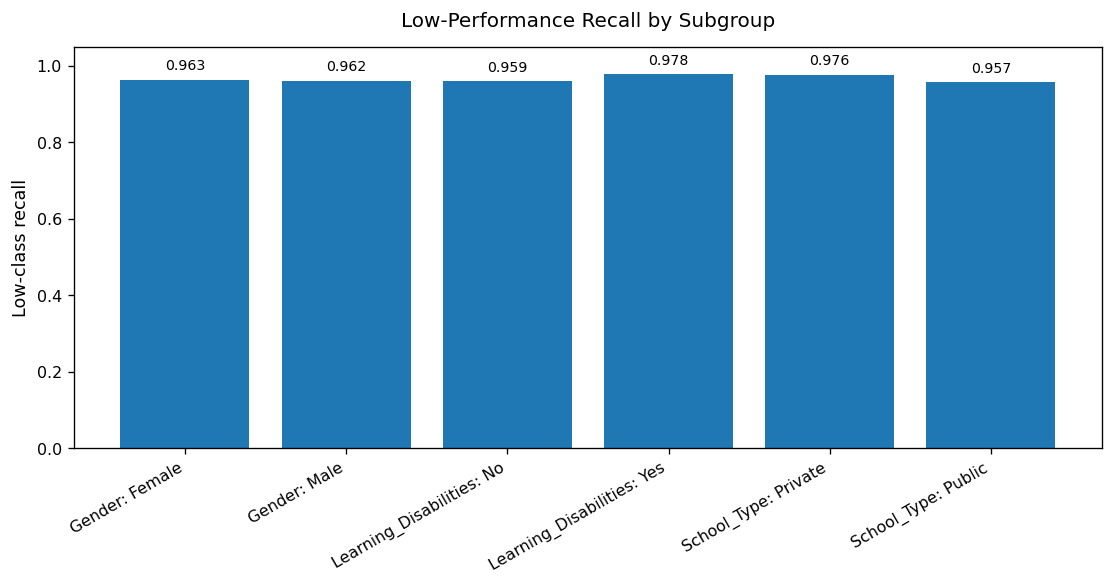

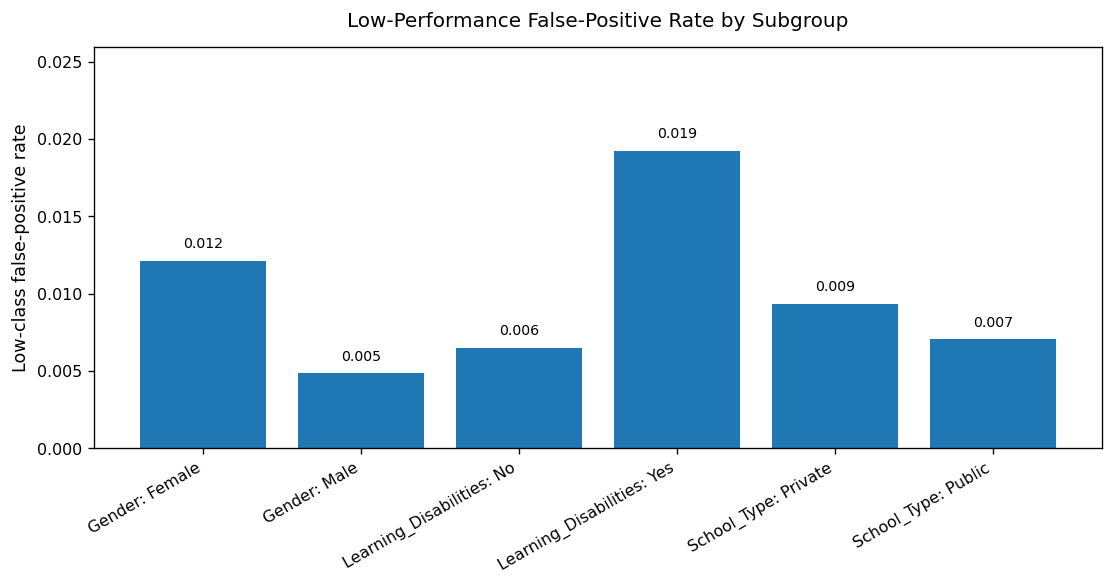

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
fair_rows=[]
test_original=df.iloc[test_idx].reset_index(drop=True)
for attribute in ['Gender','Learning_Disabilities','School_Type']:
    values=test_original[attribute].fillna('Missing').astype(str).to_numpy()
    for group in sorted(np.unique(values)):
        mask=values==group; yt=y_test[mask]; yp=y_pred[mask]
        _,_,macro_f1,_=precision_recall_fscore_support(yt,yp,average='macro',zero_division=0)
        is_low=yt==low_code; pred_low=yp==low_code
        tp=int(np.sum(is_low & pred_low)); fp=int(np.sum(~is_low & pred_low))
        fn=int(np.sum(is_low & ~pred_low)); tn=int(np.sum(~is_low & ~pred_low))
        fair_rows.append({
            'Attribute':attribute,'Group':group,'N':int(mask.sum()),
            'Accuracy':accuracy_score(yt,yp),'Macro_F1':macro_f1,
            'Low_Precision':tp/(tp+fp) if tp+fp else np.nan,
            'Low_Recall':tp/(tp+fn) if tp+fn else np.nan,
            'Low_FPR':fp/(fp+tn) if fp+tn else np.nan,
            'Actual_Low_N':int(is_low.sum())
        })
fairness=pd.DataFrame(fair_rows); display(fairness); fairness.to_csv(EVIDENCE_DIR/'fairness.csv',index=False)



labels = (fairness['Attribute'] + ': ' + fairness['Group']).tolist()
x = np.arange(len(labels))

# Separate charts prevent the very small false-positive rates
# from being visually compressed beside recall values near 1.0.
fig, ax = plt.subplots(figsize=(9.4, 5.0))
bars = ax.bar(x, fairness['Low_Recall'])
ax.set_xticks(x, labels=labels, rotation=30, ha='right')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Low-class recall')
ax.set_title('Low-Performance Recall by Subgroup', pad=12)

for bar, value in zip(bars, fairness['Low_Recall']):
    if pd.notna(value):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            min(value + 0.018, 1.025),
            f'{value:.3f}',
            ha='center',
            va='bottom',
            fontsize=8.5
        )

save_figure(fig, '13_fairness_low_recall.png')

fig, ax = plt.subplots(figsize=(9.4, 5.0))
bars = ax.bar(x, fairness['Low_FPR'])
ax.set_xticks(x, labels=labels, rotation=30, ha='right')
upper = max(float(fairness['Low_FPR'].max()) * 1.35, 0.02)
ax.set_ylim(0, upper)
ax.set_ylabel('Low-class false-positive rate')
ax.set_title('Low-Performance False-Positive Rate by Subgroup', pad=12)

for bar, value in zip(bars, fairness['Low_FPR']):
    if pd.notna(value):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + upper * 0.025,
            f'{value:.3f}',
            ha='center',
            va='bottom',
            fontsize=8.5
        )

save_figure(fig, '14_fairness_low_fpr.png')

## 15. Save the final pipeline and run summary

The complete preprocessing-plus-model pipeline is saved as one artefact so future inference applies exactly the transformations used during training. A machine-readable summary is stored with the evidence.

In [ ]:
joblib.dump(best_model, EVIDENCE_DIR / 'final_logistic_regression_pipeline.joblib')

summary = {
    'dataset_sha256': DATA_SHA256,
    'dataset_rows': int(len(df)),
    'predictors': int(X.shape[1]),
    'train_rows': int(len(X_train)),
    'test_rows': int(len(X_test)),
    'selected_model': 'Logistic Regression',
    'best_params': logistic_search.best_params_,
    'best_cv_macro_f1': float(logistic_search.best_score_),
    'test_accuracy': float(metrics.loc[0, 'Accuracy']),
    'test_balanced_accuracy': float(metrics.loc[0, 'Balanced_Accuracy']),
    'test_macro_f1': float(metrics.loc[0, 'Macro_F1']),
    'test_macro_roc_auc_ovr': float(metrics.loc[0, 'Macro_ROC_AUC_OVR']),
    'low_recall': float(report_dict['Low']['recall']),
    'low_f1': float(report_dict['Low']['f1-score']),
    'test_errors': int(len(errors)),
    'boundary_adjacent_error_share': float(errors['Boundary_Adjacent'].mean())
}

(EVIDENCE_DIR / 'final_summary.json').write_text(json.dumps(summary, indent=2))

print(json.dumps(summary, indent=2))
print()
print('Saved evidence to:', EVIDENCE_DIR.resolve())

{
  "dataset_sha256": "e8df8c4148ef83fb295ca1c092f2c6ee15272c0a8e3018b769a788ab50e96e97",
  "dataset_rows": 6607,
  "predictors": 19,
  "train_rows": 5285,
  "test_rows": 1322,
  "selected_model": "Logistic Regression",
  "best_params": {
    "model__C": 100,
    "model__class_weight": null
  },
  "best_cv_macro_f1": 0.9635913599589594,
  "test_accuracy": 0.9682299546142209,
  "test_balanced_accuracy": 0.9644608590141722,
  "test_macro_f1": 0.9667520324582349,
  "test_macro_roc_auc_ovr": 0.9939311889145155,
  "low_recall": 0.9621993127147767,
  "low_f1": 0.9671848013816926,
  "test_errors": 42,
  "boundary_adjacent_error_share": 0.8809523809523809
}

Saved evidence to: /content/ld6051_evidence


## 16. Automated integrity and reproducibility checks

These checks verify methodological conditions rather than forcing the notebook to match predetermined performance numbers. If a check fails, investigate the data, split or pipeline before interpreting the model results.

In [ ]:
assert len(df) == len(train_idx) + len(test_idx), 'Train/test row accounting failed.'
assert set(train_idx).isdisjoint(set(test_idx)), 'Train and test indices overlap.'
assert 'Exam_Score' not in X.columns, 'Target leakage: Exam_Score remains in predictors.'
assert 'Performance_Class' not in X.columns, 'Engineered label remains in predictors.'
assert int(df.duplicated().sum()) == 0, 'Unexpected duplicate rows detected.'
assert np.isfinite(metrics.select_dtypes(include=np.number).to_numpy()).all(), 'Non-finite final metric detected.'
assert logistic_search.best_estimator_ is best_model, 'Final model is not the refitted GridSearchCV estimator.'
assert len(y_pred) == len(y_test), 'Prediction/test length mismatch.'

print('All integrity checks passed.')
print('Final model:', type(best_model.named_steps['model']).__name__)
print('Best training-only parameters:', logistic_search.best_params_)
print('Evidence directory:', EVIDENCE_DIR.resolve())

All integrity checks passed.
Final model: LogisticRegression
Best training-only parameters: {'model__C': 100, 'model__class_weight': None}
Evidence directory: /content/ld6051_evidence


## 17. Methodological scope and limitations

- The Low/Medium/High thresholds are analytical categories created for this assessment; they are not official institutional grading boundaries.
- The holdout performance estimates generalisation only to unseen observations from the supplied dataset.
- The single score of 101 is retained and reported because no authoritative source rule justifies silently capping or deleting it.
- Feature importance, coefficients and correlations are predictive associations, not evidence of causal effects.
- Threshold and fairness analyses are exploratory post-hoc diagnostics and require separate validation before operational use.
- A real educational deployment would require institution-specific external validation, governance, privacy controls, human oversight and ongoing monitoring.

Run the notebook from top to bottom in Google Colab using the supplied dataset. The `ld6051_evidence` directory will contain the figures, tables, trained pipeline and reproducibility metadata used to support the group report.
